     MonthlyUsage  CustomerType  Complaints  Recharged
0            2669             1           1          1
1            1151             0           0          1
2            1584             0           1          1
3            2693             1           0          1
4             500             1           1          0
..            ...           ...         ...        ...
145          1343             2           1          1
146          1540             2           0          1
147           497             4           1          0
148          1283             0           1          1
149          2978             3           0          1

[150 rows x 4 columns]
categorical features:  []
numerical features:  ['MonthlyUsage', 'CustomerType', 'Complaints', 'Recharged']
Accuracy:  0.9555555555555556
confusion matrix:
 [[11  2]
 [ 0 32]]


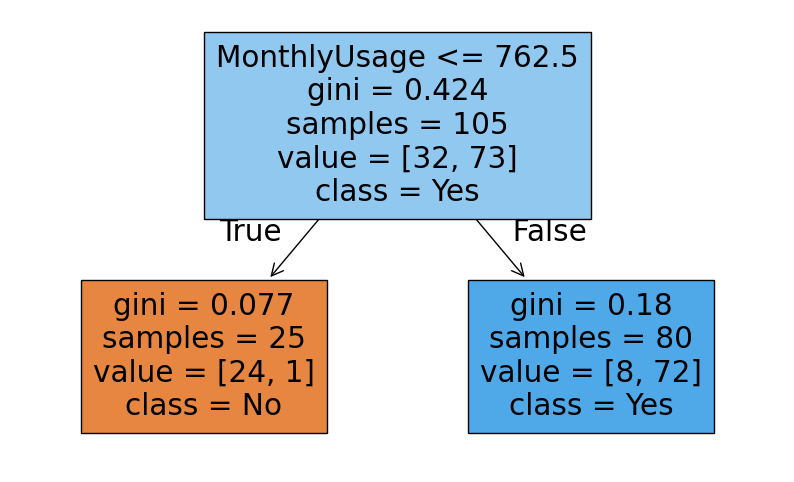

Recharge preditcion:  [1]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

data = pd.read_csv('recharge_data.csv')

# Convert categorical values into numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data['CustomerType'] = le.fit_transform(data['CustomerType'])
data['Complaints'] = le.fit_transform(data['Complaints'])
data['Recharged'] = le.fit_transform(data['Recharged'])

# Split features and label
X = data[['MonthlyUsage', 'CustomerType', 'Complaints']]
y = data['Recharged']

print(data)

X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)
model= DecisionTreeClassifier(criterion="gini",max_depth=3,min_impurity_decrease=0.07,min_samples_leaf=5,max_leaf_nodes=2)
model.fit(X_train,y_train)

categorical= data.select_dtypes(include='object').columns
numerical=data.select_dtypes(exclude='object').columns
print("categorical features: ",list(categorical))
print("numerical features: ",list(numerical))

y_pred= model.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix
print('Accuracy: ',accuracy_score(y_test,y_pred))
print('confusion matrix:\n',confusion_matrix(y_test,y_pred))

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(model,feature_names=['MonthlyUsage','CustomerType','Complaints'], class_names=['No','Yes'], filled=True)
plt.show()

new_data=[[1000,2,3]]
print('Recharge preditcion: ', model.predict(new_data))